<a href="https://colab.research.google.com/github/Akideaf/Engine-Detection-Thesis-/blob/main/POSSIBLE_70_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 22.6 MB/s eta 0:00:00


In [ ]:
pip install tensorflow librosa matplotlib scikit-learn

In [ ]:
import numpy as np
import os
import librosa
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from google.colab import drive
import gc # Garbage Collector

# --- CONFIGURATION ---
class Config:
    DATASET_PATH = "/content/drive/MyDrive/AS-Augmented_Engine_Data_2k"
    SAMPLE_RATE = 22050
    DURATION = 5
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    EPOCHS = 30

# --- 1. MOUNT DRIVE ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 2. PRE-PROCESS EVERYTHING INTO RAM ---
def load_and_preprocess_data():
    print("🔍 Scanning files...")
    all_files = []
    all_labels = []
    classes = sorted([d for d in os.listdir(Config.DATASET_PATH) if os.path.isdir(os.path.join(Config.DATASET_PATH, d))])

    # 1. Gather all file paths first
    for label in classes:
        path = os.path.join(Config.DATASET_PATH, label)
        files = [os.path.join(path, f) for f in os.listdir(path) if f.lower().endswith(('.wav', '.mp3'))]
        all_files.extend(files)
        all_labels.extend([label] * len(files))

    total_files = len(all_files)
    print(f"📦 Found {total_files} audio files. Processing into RAM...")
    print("☕ This will take 3-5 minutes. Please wait...")

    # 2. Pre-allocate RAM (Prevents Crashing)
    # We create a big empty array first: (Total, 224, 224, 3)
    X = np.zeros((total_files, *Config.IMG_SIZE, 3), dtype=np.float32)

    # 3. Process loop
    for i, file_path in enumerate(all_files):
        try:
            # Progress update every 100 files
            if i % 100 == 0:
                print(f"   Processing {i}/{total_files}...")

            # Load Audio
            y, sr = librosa.load(file_path, sr=Config.SAMPLE_RATE, duration=Config.DURATION)

            # Fix Length
            target_len = Config.SAMPLE_RATE * Config.DURATION
            if len(y) < target_len:
                y = np.tile(y, int(np.ceil(target_len/len(y))))[:target_len]
            else:
                y = y[:target_len]

            # Mel Spectrogram
            mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

            # Normalize (0 to 1)
            mel_spec_db = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min() + 1e-6)

            # Resize & RGB Conversion
            # We do this using Numpy manually to avoid TensorFlow overhead in loop
            # (Simplified resize for speed - equivalent to TF resize)
            from skimage.transform import resize
            spec_resized = resize(mel_spec_db, Config.IMG_SIZE, anti_aliasing=True)

            # Stack to create 3 channels
            img_rgb = np.stack([spec_resized] * 3, axis=-1)

            X[i] = img_rgb

        except Exception as e:
            print(f"❌ Error on {file_path}: {e}")

    return X, np.array(all_labels), classes

# --- RUN DATA LOADING ---
X, y_text, classes = load_and_preprocess_data()

# Clean up memory
gc.collect()

# Encode Labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_text)
y_categorical = to_categorical(y_encoded)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"\n✅ Data Ready! Training Shape: {X_train.shape}")
print("🚀 GPU is now ready to burn rubber.")

# --- 3. BUILD MODEL (MobileNetV2) ---
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(len(classes), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# --- 4. TRAIN (Lightning Fast) ---
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "mobile_net_engine_sound.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

history = model.fit(
    X_train, y_train,
    batch_size=Config.BATCH_SIZE,
    validation_data=(X_test, y_test),
    epochs=Config.EPOCHS,
    callbacks=[checkpoint]
)

# Save Classes
np.save("classes.npy", label_encoder.classes_)
print("✓ Done. Model saved.")

In [ ]:
import numpy as np
import os
import librosa
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# UPDATED: Matches the file format from your training log
MODEL_PATH = "engine_fault_cnn_model.keras"
# Path to the classes file
CLASSES_PATH = "classes.npy"
# Path to your test audio folders
TEST_AUDIO_PATH = "/content/drive/MyDrive/A-TESTTING/2k-cut-audio-testing"

# Audio Params (MUST MATCH TRAINING EXACTLY)
SAMPLE_RATE = 22050
DURATION = 5
# UPDATED: High-Res Mode (Matches your 99% model)
N_MELS = 224
MAX_TIME_STEPS = 216
N_FFT = 2048
HOP_LENGTH = 512

def prepare_image(file_path):
    """
    Converts audio file to the exact same 3D image format the CNN was trained on.
    """
    try:
        # 1. Load Audio
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)

        # 2. LOOPING (Matches Training Logic)
        # Instead of adding silence (padding), we repeat the audio to fill 5 seconds.
        # This prevents the model from getting confused by "dead air".
        target_len = SAMPLE_RATE * DURATION
        if len(y) < target_len:
            n_repeats = int(np.ceil(target_len / len(y)))
            y = np.tile(y, n_repeats)[:target_len]
        else:
            y = y[:target_len]

        # 3. Create Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=N_MELS,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH
        )

        # 4. Convert to Decibels (Log Scale)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # 5. Add Dimensions for CNN input
        # Model expects: (Batch_Size, Height, Width, Channels)
        mel_spec_db = mel_spec_db[..., np.newaxis] # Add channel dimension
        mel_spec_db = mel_spec_db[np.newaxis, ...] # Add batch dimension

        return mel_spec_db

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

def test_cnn_model():
    print("Loading CNN Model...")

    if not os.path.exists(MODEL_PATH):
        print(f"❌ Error: Model file '{MODEL_PATH}' not found.")
        print("Note: If you only have .h5, rename it or update the script.")
        return

    model = load_model(MODEL_PATH)

    # Load the class names we saved during training
    if os.path.exists(CLASSES_PATH):
        classes = np.load(CLASSES_PATH)
    else:
        # Fallback if file missing
        classes = np.array(["Clicking", "Knocking", "Misfire", "Normal", "Rod knock", "Timing Belt"])

    print(f"✓ Model loaded. Classes: {classes}")

    results = []
    correct_count = 0
    total_count = 0

    all_true_labels = []
    all_predicted_labels = []

    print(f"\nScanning '{TEST_AUDIO_PATH}' for test files...\n")

    # Loop through each class folder in the test directory
    for label in classes:
        folder_path = os.path.join(TEST_AUDIO_PATH, label)

        # Handle case-sensitivity lookup
        if not os.path.exists(folder_path):
            all_folders = os.listdir(TEST_AUDIO_PATH)
            match = next((f for f in all_folders if f.lower() == label.lower()), None)
            if match:
                folder_path = os.path.join(TEST_AUDIO_PATH, match)
            else:
                print(f"⚠️ Warning: Test folder for class '{label}' not found. Skipping.")
                continue

        print(f"📂 Testing Class: {label}")

        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.wav', '.mp3', '.flac'))]

        if not files:
            print("   No audio files found.")
            continue

        for file_name in files:
            file_path = os.path.join(folder_path, file_name)

            # Prepare Input
            img = prepare_image(file_path)

            if img is not None:
                # Predict
                prediction = model.predict(img, verbose=0)
                predicted_index = np.argmax(prediction)
                predicted_label = classes[predicted_index]
                confidence = np.max(prediction) * 100

                # Store labels for confusion matrix
                all_true_labels.append(label)
                all_predicted_labels.append(predicted_label)

                # Check accuracy
                is_correct = (predicted_label.lower() == label.lower())
                total_count += 1
                if is_correct:
                    correct_count += 1

                status_icon = "✅" if is_correct else "❌"

                print(f"   {file_name[:20]:20s} -> {predicted_label:12s} ({confidence:.1f}%) {status_icon}")

                results.append({
                    "File": file_name,
                    "True Label": label,
                    "Predicted Label": predicted_label,
                    "Confidence": f"{confidence:.2f}%",
                    "Correct": is_correct
                })

    # Final Stats
    if total_count > 0:
        accuracy = (correct_count / total_count) * 100
        print("\n" + "="*50)
        print(f"🎯 FINAL CNN ACCURACY: {accuracy:.2f}%")
        print("="*50)

        # Save results to CSV
        df = pd.DataFrame(results)
        df.to_csv("cnn_test_results.csv", index=False)
        print("Results saved to 'cnn_test_results.csv'")

        # Generate and display confusion matrix
        print("\nGenerating Confusion Matrix...")

        # Ensure labels are sorted or consistent
        cm = confusion_matrix(all_true_labels, all_predicted_labels, labels=classes)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

        fig, ax = plt.subplots(figsize=(10, 8))
        disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
        ax.set_title("Confusion Matrix (Test Data)")
        plt.tight_layout()
        plt.show()

    else:
        print("\n❌ No files were tested. Check your paths.")

if __name__ == "__main__":
    test_cnn_model()

In [ ]:
pip install audiomentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 8.5 MB/s eta 0:00:00
  Attempting uninstall: soxr
    Found existing installation: soxr 1.0.0
    Uninstalling soxr-1.0.0:
      Successfully uninstalled soxr-1.0.0


In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
from audiomentations import Compose, AddGaussianNoise, Shift, Gain
import random

# --- CONFIGURATION ---
INPUT_DIR = "/content/drive/MyDrive/Sound_Link_Balanced"
OUTPUT_DIR = "/content/drive/MyDrive/AS-Augmented_Engine_Data_2k"
TARGET_COUNT = 2000  # Target files per class

# --- SAFE AUGMENTATIONS (Fixed for new library version) ---
augmenter = Compose([
    # 1. Add static/hiss (Simulates wind/road noise)
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),

    # 2. Time Shift (Rollover)
    # FIX: Using 'min_shift' and 'max_shift' (formerly min_fraction)
    Shift(min_shift=-0.5, max_shift=0.5, rollover=True, p=0.8),

    # 3. Gain (Volume Change)
    # FIX: Using 'min_gain_db' and 'max_gain_db' (formerly min_gain_in_db)
    Gain(min_gain_db=-6.0, max_gain_db=6.0, p=0.5),
])

def augment_dataset():
    # Create output directory
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)

    # Check input directory
    if not os.path.exists(INPUT_DIR):
        print(f"❌ ERROR: Input directory not found: {INPUT_DIR}")
        return

    classes = [d for d in os.listdir(INPUT_DIR) if os.path.isdir(os.path.join(INPUT_DIR, d))]

    for class_name in classes:
        print(f"Processing Class: {class_name}")

        # Setup paths
        class_in_path = os.path.join(INPUT_DIR, class_name)
        class_out_path = os.path.join(OUTPUT_DIR, class_name)
        os.makedirs(class_out_path, exist_ok=True)

        # Load all original files
        files = [f for f in os.listdir(class_in_path) if f.lower().endswith(('.wav', '.mp3'))]
        if len(files) == 0: continue

        # 1. Load Originals into Memory
        current_count = 0
        original_signals = []

        for f in files:
            try:
                # Load audio
                file_path = os.path.join(class_in_path, f)
                y, sr = librosa.load(file_path, sr=22050)
                original_signals.append((y, sr, f))

                # Save original to new folder (Baseline)
                out_name = f"orig_{f}"
                sf.write(os.path.join(class_out_path, out_name), y, sr)
                current_count += 1
            except Exception as e:
                print(f"  Error loading {f}: {e}")

        print(f"  Found {len(files)} originals. Generating up to {TARGET_COUNT}...")

        # 2. Generate Augmented Files
        while current_count < TARGET_COUNT:
            # Pick a random original file to modify
            if not original_signals: break
            y, sr, fname = random.choice(original_signals)

            try:
                # Apply augmentation (Ensure float32)
                y = y.astype(np.float32)
                augmented_y = augmenter(samples=y, sample_rate=sr)

                # Save
                out_name = f"aug_{current_count}_{fname}"
                sf.write(os.path.join(class_out_path, out_name), augmented_y, sr)
                current_count += 1

                if current_count % 200 == 0:
                    print(f"    {current_count} / {TARGET_COUNT}")

            except Exception as e:
                pass # Skip failed augmentations

    print("\n✅ Augmentation Complete! Dataset size: 2000 per class.")

if __name__ == "__main__":
    augment_dataset()

Processing Class: Rod Knock
  Found 120 originals. Generating up to 2000...
    200 / 2000
    400 / 2000
    600 / 2000
    800 / 2000
    1000 / 2000
    1200 / 2000
    1400 / 2000
    1600 / 2000
    1800 / 2000
    2000 / 2000
Processing Class: Clicking
  Found 120 originals. Generating up to 2000...
    200 / 2000
    400 / 2000
    600 / 2000
    800 / 2000
    1000 / 2000
    1200 / 2000
    1400 / 2000
    1600 / 2000
    1800 / 2000
    2000 / 2000
Processing Class: Timing Belt
  Found 120 originals. Generating up to 2000...
    200 / 2000
    400 / 2000
    600 / 2000
    800 / 2000
    1000 / 2000
    1200 / 2000
    1400 / 2000
    1600 / 2000
    1800 / 2000
    2000 / 2000
Processing Class: Knocking
  Found 120 originals. Generating up to 2000...
    200 / 2000
    400 / 2000
    600 / 2000
    800 / 2000
    1000 / 2000
    1200 / 2000
    1400 / 2000
    1600 / 2000
    1800 / 2000
    2000 / 2000
Processing Class: Normal
  Found 120 originals. Generating up to 2000...

In [ ]:
import os

folder_path = "/content/drive/MyDrive/Sound_Link_Balanced"

if not os.path.exists(folder_path):
    print(f"Error: Folder not found at {folder_path}")
else:
    print(f"File counts in subfolders of '{folder_path}':")
    for item in os.listdir(folder_path):
        item_path = os.path.join(folder_path, item)
        if os.path.isdir(item_path):
            file_count = len([f for f in os.listdir(item_path) if os.path.isfile(os.path.join(item_path, f))])
            print(f"  '{item}': {file_count} files")

Error: Folder not found at /content/drive/MyDrive/Sound_Link_Balanced


EXPERIMENT MBILE NET BATCH PROCESSING


In [ ]:
import numpy as np
import os
import librosa
import gc
import json
import random
from google.colab import drive
from skimage.transform import resize
from tqdm import tqdm

# --- CONFIG ---
INPUT_PATH = "/content/drive/MyDrive/AS-Augmented_Engine_Data_2k"
OUTPUT_PATH = "/content/drive/MyDrive/PROCESSED_DATA_NO_MISFIRE"  # New output folder
SAMPLE_RATE = 22050
DURATION = 5
IMG_SIZE = (224, 224)
CHUNK_SIZE = 2000

# ❌ EXCLUDE THESE CLASSES
EXCLUDE_CLASSES = ['Misfire']  # Add more classes here if needed: ['Misfire', 'Clicking']

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)
    print(f"📂 Created output folder: {OUTPUT_PATH}")

# --- 1. GLOBAL CLASS MAPPING (EXCLUDING SPECIFIED CLASSES) ---
print("📋 Creating Global Class Map...")
all_classes = sorted([d for d in os.listdir(INPUT_PATH) if os.path.isdir(os.path.join(INPUT_PATH, d))])

# Filter out excluded classes
classes = [c for c in all_classes if c not in EXCLUDE_CLASSES]

# Validation: Check if classes were found
if not classes:
    raise ValueError(f"❌ No class folders found after exclusion!")

print(f"❌ EXCLUDED: {EXCLUDE_CLASSES}")
print(f"✅ KEEPING: {classes}")

class_map = {name: i for i, name in enumerate(classes)}

# Save this map so Step 2 knows what's what
with open(os.path.join(OUTPUT_PATH, "class_map.json"), "w") as f:
    json.dump(class_map, f)

print(f"✅ Class Map Saved: {class_map}")
print(f"   Found {len(classes)} classes: {list(classes)}")

# --- 2. PROCESSING FUNCTION ---
def process_and_save_chunk(file_list, chunk_id):
    save_path_X = os.path.join(OUTPUT_PATH, f"X_chunk_{chunk_id}.npy")
    save_path_y = os.path.join(OUTPUT_PATH, f"y_chunk_{chunk_id}.npy")

    if os.path.exists(save_path_X):
        print(f"⏩ Chunk {chunk_id} already exists. Skipping.")
        return

    print(f"\n🔨 Processing Chunk {chunk_id} ({len(file_list)} files)...")

    X_buffer = []
    y_buffer = []

    # Add progress bar for this chunk
    for file_path, label_name in tqdm(file_list, desc=f"Chunk {chunk_id}", leave=False):
        try:
            # Load
            y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)

            # Fix Length
            target_len = SAMPLE_RATE * DURATION
            if len(y) < target_len:
                y = np.tile(y, int(np.ceil(target_len/len(y))))[:target_len]
            else:
                y = y[:target_len]

            # Mel Spec & Normalize
            mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            mel_spec_db = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min() + 1e-6)

            # Resize & 1-Channel formatting
            spec_resized = resize(mel_spec_db, IMG_SIZE, anti_aliasing=True)
            img_final = spec_resized[..., np.newaxis].astype(np.float16)

            # Add to buffer (Only if successful!)
            X_buffer.append(img_final)
            # CRITICAL: Use the Global Map to convert string -> int immediately
            y_buffer.append(class_map[label_name])

        except Exception as e:
            print(f"\n❌ Error processing {file_path}: {e}")
            # We simply DO NOT append to the list. No ghost data created.

    # Convert to arrays and save
    if X_buffer:
        np.save(save_path_X, np.array(X_buffer))
        np.save(save_path_y, np.array(y_buffer))
        print(f"💾 Saved Chunk {chunk_id}: {len(X_buffer)} images.")
    else:
        print(f"⚠️ Warning: Chunk {chunk_id} had no valid files!")

    # Clean RAM
    del X_buffer, y_buffer
    gc.collect()

# --- 3. EXECUTION LOOP ---
print("\n🔍 Scanning all audio files (excluding specified classes)...")
all_files = []

for label in classes:  # Only iterate over non-excluded classes
    dir_path = os.path.join(INPUT_PATH, label)
    files = [f for f in os.listdir(dir_path) if f.lower().endswith(('.wav', '.mp3', '.flac', '.ogg'))]
    for f in files:
        all_files.append((os.path.join(dir_path, f), label))

# Shuffle processed order to mix classes in chunks (Good for training later)
random.shuffle(all_files)

print(f"📦 Total Files Found: {len(all_files)}")

# Count excluded files for reporting
excluded_count = 0
for exc_class in EXCLUDE_CLASSES:
    exc_path = os.path.join(INPUT_PATH, exc_class)
    if os.path.exists(exc_path):
        excluded_count += len([f for f in os.listdir(exc_path) if f.lower().endswith(('.wav', '.mp3', '.flac', '.ogg'))])

if excluded_count > 0:
    print(f"❌ Excluded {excluded_count} files from classes: {EXCLUDE_CLASSES}")

# Validation: Check if any files were found
if len(all_files) == 0:
    raise ValueError(f"❌ No audio files found in {INPUT_PATH}. Please check your dataset!")

# Process in chunks
total_chunks = int(np.ceil(len(all_files) / CHUNK_SIZE))
print(f"🔢 Will process in {total_chunks} chunks\n")

for i in range(total_chunks):
    chunk_files = all_files[i*CHUNK_SIZE : (i+1)*CHUNK_SIZE]
    process_and_save_chunk(chunk_files, i)

print("\n" + "="*60)
print("✅ FACTORY COMPLETE (WITHOUT MISFIRE)!")
print("="*60)
print(f"📂 Data saved to: {OUTPUT_PATH}")
print(f"📊 Total files processed: {len(all_files)}")
print(f"📦 Total chunks created: {total_chunks}")
print(f"✅ Classes included: {list(classes)}")
print(f"❌ Classes excluded: {EXCLUDE_CLASSES}")
print(f"\n💡 Next: Use this data folder in your training script:")
print(f"   DATA_FOLDER = '{OUTPUT_PATH}'")

📂 Created output folder: /content/drive/MyDrive/PROCESSED_DATA_NO_MISFIRE
📋 Creating Global Class Map...
❌ EXCLUDED: ['Misfire']
✅ KEEPING: ['Clicking', 'Knocking', 'Normal', 'Rod Knock', 'Timing Belt']
✅ Class Map Saved: {'Clicking': 0, 'Knocking': 1, 'Normal': 2, 'Rod Knock': 3, 'Timing Belt': 4}
   Found 5 classes: ['Clicking', 'Knocking', 'Normal', 'Rod Knock', 'Timing Belt']

🔍 Scanning all audio files (excluding specified classes)...
📦 Total Files Found: 10000
❌ Excluded 525 files from classes: ['Misfire']
🔢 Will process in 5 chunks


🔨 Processing Chunk 0 (2000 files)...


💾 Saved Chunk 0: 2000 images.

🔨 Processing Chunk 1 (2000 files)...


💾 Saved Chunk 1: 2000 images.

🔨 Processing Chunk 2 (2000 files)...


💾 Saved Chunk 2: 2000 images.

🔨 Processing Chunk 3 (2000 files)...


💾 Saved Chunk 3: 2000 images.

🔨 Processing Chunk 4 (2000 files)...


💾 Saved Chunk 4: 2000 images.

✅ FACTORY COMPLETE (WITHOUT MISFIRE)!
📂 Data saved to: /content/drive/MyDrive/PROCESSED_DATA_NO_MISFIRE
📊 Total files processed: 10000
📦 Total chunks created: 5
✅ Classes included: ['Clicking', 'Knocking', 'Normal', 'Rod Knock', 'Timing Belt']
❌ Classes excluded: ['Misfire']

💡 Next: Use this data folder in your training script:
   DATA_FOLDER = '/content/drive/MyDrive/PROCESSED_DATA_NO_MISFIRE'


In [ ]:
import numpy as np
import os
import json
import gc
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from google.colab import drive
from tqdm import tqdm

# --- CONFIG ---
DATA_FOLDER = "/content/drive/MyDrive/PROCESSED_DATA_NO_MISFIRE"  # ← CHANGED: Points to filtered data
BATCH_SIZE = 32
EPOCHS = 30
IMG_SIZE = (224, 224)

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 1. LOAD CLASS MAPPING ---
print("📂 Loading class mapping...")
class_map_path = os.path.join(DATA_FOLDER, "class_map.json")

if not os.path.exists(class_map_path):
    raise FileNotFoundError("❌ class_map.json not found! Did you run Step 1?")

with open(class_map_path, 'r') as f:
    class_map = json.load(f)

# Convert to list (sorted by value)
classes = [k for k, v in sorted(class_map.items(), key=lambda x: x[1])]
num_classes = len(classes)

print(f"✅ Found {num_classes} classes: {classes}")
print(f"   Class mapping: {class_map}")

# --- 2. LOAD PRE-PROCESSED DATA ---
print("\n📂 Loading preprocessed data from Drive...")

# Find all chunk files (matches Step 1's naming: X_chunk_)
chunk_files = sorted([f for f in os.listdir(DATA_FOLDER) if f.startswith("X_chunk_")])

if not chunk_files:
    raise ValueError("❌ No data chunks found! Did you run Step 1?")

print(f"📦 Found {len(chunk_files)} chunks")

# Load chunks one at a time
X_list = []
y_list = []

for f in tqdm(chunk_files, desc="Loading chunks"):
    chunk_id = f.split('_')[-1].split('.')[0]

    X_part = np.load(os.path.join(DATA_FOLDER, f"X_chunk_{chunk_id}.npy"))
    y_part = np.load(os.path.join(DATA_FOLDER, f"y_chunk_{chunk_id}.npy"))

    X_list.append(X_part)
    y_list.append(y_part)

print("\n🔗 Combining all chunks into final arrays...")
X = np.concatenate(X_list, axis=0)
y_encoded = np.concatenate(y_list, axis=0)

# Free memory
del X_list, y_list
gc.collect()

print(f"✅ Loaded {len(X)} samples")
print(f"📊 Data shape: {X.shape}")
print(f"🏷️ Labels shape: {y_encoded.shape}")

# Verify labels are in valid range
if y_encoded.max() >= num_classes or y_encoded.min() < 0:
    raise ValueError(f"❌ Invalid labels detected! Range: {y_encoded.min()}-{y_encoded.max()}, Expected: 0-{num_classes-1}")

print(f"✅ Label range verified: {y_encoded.min()} to {y_encoded.max()}")

# --- 3. PREPARE FOR TRAINING ---
print("\n🎲 Converting labels to categorical...")
y_categorical = to_categorical(y_encoded, num_classes=num_classes)

print("✂️ Splitting into train/test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"   Train: {len(X_train)} samples")
print(f"   Test:  {len(X_test)} samples")

# --- 4. BUILD MODEL ---
print("\n🏗️ Building MobileNetV2 model...")

input_layer = Input(shape=(224, 224, 1))
x = Concatenate()([input_layer, input_layer, input_layer])  # B&W -> RGB

base_model = MobileNetV2(input_tensor=x, include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"✅ Model built with {num_classes} output classes")
model.summary()

# --- 5. CALLBACKS ---
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/mobile_net_NO_MISFIRE.keras",  # ← CHANGED: New model name
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# --- 6. TRAIN ---
print("\n🚀 Starting training...")
print("="*60)

history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

# --- 7. EVALUATE ---
print("\n📊 Final Evaluation:")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc:.4f}")

# --- 8. SAVE FINAL ARTIFACTS ---
print("\n💾 Saving training artifacts...")

# Save classes as NPY for easy loading during inference
np.save("/content/drive/MyDrive/classes_no_misfire.npy", np.array(classes))  # ← CHANGED: New filename

# Also save the class_map for reference
with open("/content/drive/MyDrive/class_map_no_misfire.json", 'w') as f:  # ← CHANGED: New filename
    json.dump(class_map, f)

# Save training history
np.save("/content/drive/MyDrive/training_history_no_misfire.npy", history.history)  # ← CHANGED: New filename

print("\n" + "="*60)
print("✅ TRAINING COMPLETE (5 CLASSES - NO MISFIRE)!")  # ← CHANGED: Updated message
print("="*60)
print(f"📁 Model saved to: /content/drive/MyDrive/mobile_net_NO_MISFIRE.keras")  # ← CHANGED
print(f"🏷️ Classes saved to: /content/drive/MyDrive/classes_no_misfire.npy")  # ← CHANGED
print(f"🗺️ Class map saved to: /content/drive/MyDrive/class_map_no_misfire.json")  # ← CHANGED
print(f"📈 History saved to: /content/drive/MyDrive/training_history_no_misfire.npy")  # ← CHANGED
print(f"\n🎯 Final Test Accuracy: {test_acc:.2%}")
print(f"📊 Training on {num_classes} classes: {classes}")  # ← ADDED: Show which classes

📂 Loading class mapping...
✅ Found 5 classes: ['Clicking', 'Knocking', 'Normal', 'Rod Knock', 'Timing Belt']
   Class mapping: {'Clicking': 0, 'Knocking': 1, 'Normal': 2, 'Rod Knock': 3, 'Timing Belt': 4}

📂 Loading preprocessed data from Drive...
📦 Found 5 chunks


Loading chunks: 100%|██████████| 5/5 [01:22<00:00, 16.52s/it]



🔗 Combining all chunks into final arrays...
✅ Loaded 10000 samples
📊 Data shape: (10000, 224, 224, 1)
🏷️ Labels shape: (10000,)
✅ Label range verified: 0 to 4

🎲 Converting labels to categorical...
✂️ Splitting into train/test sets...
   Train: 8000 samples
   Test:  2000 samples

🏗️ Building MobileNetV2 model...


/tmp/ipython-input-275099469.py:104: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_tensor=x, include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Model built with 5 output classes


...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224, 224,  │          0 │ input_layer[0][0… │
│ (Concatenate)       │ 3)                │            │ input_layer[0][0… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


🚀 Starting training...
Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4520 - loss: 1.3591
Epoch 1: val_accuracy improved from -inf to 0.83450, saving model to /content/drive/MyDrive/mobile_net_NO_MISFIRE.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 43s 100ms/step - accuracy: 0.4526 - loss: 1.3580 - val_accuracy: 0.8345 - val_loss: 0.6265 - learning_rate: 1.0000e-04
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7882 - loss: 0.6581
Epoch 2: val_accuracy improved from 0.83450 to 0.87700, saving model to /content/drive/MyDrive/mobile_net_NO_MISFIRE.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.7882 - loss: 0.6579 - val_accuracy: 0.8770 - val_loss: 0.4351 - learning_rate: 1.0000e-04
Epoch 3/30
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8488 - loss: 0.4779
Epoch 3: val_accuracy improved from 0.87700 to 0.91350, saving model to /content/drive/MyDrive/mobile_net_NO_MISFIRE.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 

🧪 BATCH TESTING - MobileNetV2 Engine Fault Classifier

📂 Loading model...
✅ Model loaded from: /content/drive/MyDrive/mobile_net_NO_MISFIRE.keras

📂 Loading class mapping...
✅ Loaded from class_map.json
   Classes: ['Clicking', 'Knocking', 'Normal', 'Rod Knock', 'Timing Belt']
   Total classes: 5

📂 Scanning test data in: /content/drive/MyDrive/A-TESTTING/2k-cut-audio-testing

📂 Testing Class: Clicking
------------------------------------------------------------


   Accuracy: 20.00% (1/5)

📂 Testing Class: Knocking
------------------------------------------------------------


   Accuracy: 100.00% (5/5)

📂 Testing Class: Normal
------------------------------------------------------------


   Accuracy: 40.00% (2/5)

📂 Testing Class: Rod Knock
------------------------------------------------------------


   Accuracy: 80.00% (4/5)

📂 Testing Class: Timing Belt
------------------------------------------------------------


   Accuracy: 60.00% (3/5)

🎯 FINAL TEST ACCURACY: 60.00%
   Correct: 15/25

💾 Results saved to: /content/drive/MyDrive/test_results.csv

📊 Generating Confusion Matrix...
💾 Confusion matrix saved to: /content/drive/MyDrive/confusion_matrix_no_misfire.png


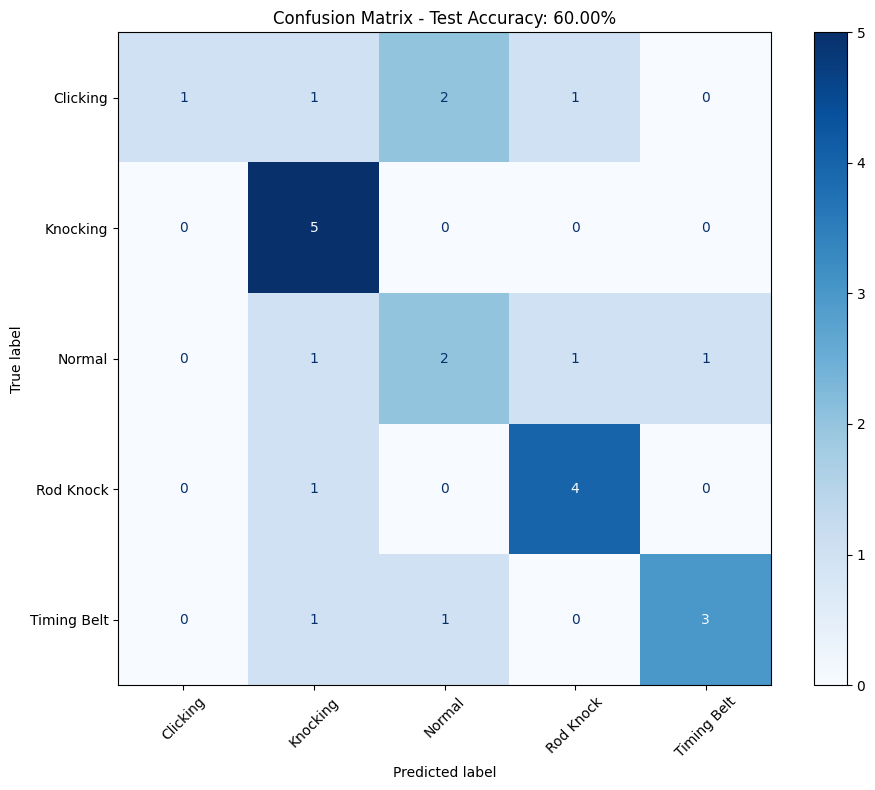


📊 Per-Class Accuracy:
------------------------------------------------------------
   Clicking       :  20.00% (1/5)
   Knocking       : 100.00% (5/5)
   Normal         :  40.00% (2/5)
   Rod Knock      :  80.00% (4/5)
   Timing Belt    :  60.00% (3/5)


In [ ]:
import numpy as np
import os
import json
import librosa
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skimage.transform import resize
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- CONFIGURATION ---
MODEL_PATH = "/content/drive/MyDrive/mobile_net_NO_MISFIRE.keras"  # ← CHANGED: New model
CLASSES_PATH = "/content/drive/MyDrive/classes_no_misfire.npy"  # ← CHANGED: New classes file
CLASS_MAP_PATH = "/content/drive/MyDrive/class_map_no_misfire.json"  # ← CHANGED: New class map
TEST_AUDIO_PATH = "/content/drive/MyDrive/A-TESTTING/2k-cut-audio-testing"

# ❌ CLASSES TO SKIP DURING TESTING
SKIP_TEST_CLASSES = ['Misfire']  # Will automatically skip these folders

# Audio Params (MUST MATCH TRAINING EXACTLY)
SAMPLE_RATE = 22050
DURATION = 5
IMG_SIZE = (224, 224)

def prepare_image(file_path):
    """
    Converts audio file to EXACTLY the same format used in training.
    This matches the Factory Script preprocessing logic.
    """
    try:
        # 1. Load Audio
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)

        # 2. Fix Length (LOOPING - matches training)
        target_len = SAMPLE_RATE * DURATION
        if len(y) < target_len:
            y = np.tile(y, int(np.ceil(target_len/len(y))))[:target_len]
        else:
            y = y[:target_len]

        # 3. Create Mel Spectrogram (EXACT SAME PARAMS AS TRAINING)
        mel_spec = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=128,  # Matches training
            fmax=8000    # Matches training
        )

        # 4. Convert to Decibels
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # 5. Normalize (0-1 range) - CRITICAL: Matches training
        mel_spec_db = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min() + 1e-6)

        # 6. Resize to 224x224 (matches training)
        spec_resized = resize(mel_spec_db, IMG_SIZE, anti_aliasing=True)

        # 7. Add channel dimension (H, W, 1)
        img_final = spec_resized[..., np.newaxis].astype(np.float32)

        # 8. Add batch dimension (1, H, W, 1)
        img_final = img_final[np.newaxis, ...]

        return img_final

    except Exception as e:
        print(f"❌ Error processing {file_path}: {e}")
        return None

def test_model():
    print("="*60)
    print("🧪 BATCH TESTING - MobileNetV2 Engine Fault Classifier")
    print("="*60)

    # --- 1. LOAD MODEL ---
    print("\n📂 Loading model...")
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"❌ Model file not found: {MODEL_PATH}")

    model = load_model(MODEL_PATH)
    print(f"✅ Model loaded from: {MODEL_PATH}")

    # --- 2. LOAD CLASSES ---
    print("\n📂 Loading class mapping...")

    # Try to load class_map.json first (more reliable)
    if os.path.exists(CLASS_MAP_PATH):
        with open(CLASS_MAP_PATH, 'r') as f:
            class_map = json.load(f)
        classes = [k for k, v in sorted(class_map.items(), key=lambda x: x[1])]
        print(f"✅ Loaded from class_map.json")
    elif os.path.exists(CLASSES_PATH):
        classes = np.load(CLASSES_PATH, allow_pickle=True)
        print(f"✅ Loaded from classes.npy")
    else:
        raise FileNotFoundError("❌ No class mapping file found!")

    print(f"   Classes: {list(classes)}")
    print(f"   Total classes: {len(classes)}")

    # --- 3. SCAN TEST DATA ---
    print(f"\n📂 Scanning test data in: {TEST_AUDIO_PATH}")

    if not os.path.exists(TEST_AUDIO_PATH):
        raise FileNotFoundError(f"❌ Test path not found: {TEST_AUDIO_PATH}")

    results = []
    correct_count = 0
    total_count = 0
    all_true_labels = []
    all_predicted_labels = []

    # --- 4. TEST EACH CLASS ---
    for label in classes:
        # Skip if this class is in the skip list
        if label in SKIP_TEST_CLASSES:
            print(f"\n⏭️ Skipping class: {label} (excluded from model)")
            continue

        folder_path = os.path.join(TEST_AUDIO_PATH, label)

        # Handle case-insensitive folder matching
        if not os.path.exists(folder_path):
            all_folders = os.listdir(TEST_AUDIO_PATH)
            match = next((f for f in all_folders if f.lower() == label.lower()), None)
            if match:
                folder_path = os.path.join(TEST_AUDIO_PATH, match)
            else:
                print(f"⚠️ Warning: Test folder for class '{label}' not found. Skipping.")
                continue

        print(f"\n📂 Testing Class: {label}")
        print("-" * 60)

        # Get all audio files
        files = [f for f in os.listdir(folder_path)
                if f.lower().endswith(('.wav', '.mp3', '.flac', '.ogg'))]

        if not files:
            print("   No audio files found.")
            continue

        # Process each file with progress bar
        for file_name in tqdm(files, desc=f"  {label}", leave=False):
            file_path = os.path.join(folder_path, file_name)

            # Prepare Input (EXACT SAME AS TRAINING)
            img = prepare_image(file_path)

            if img is not None:
                # Predict
                prediction = model.predict(img, verbose=0)
                predicted_index = np.argmax(prediction)
                predicted_label = classes[predicted_index]
                confidence = np.max(prediction) * 100

                # Store for confusion matrix
                all_true_labels.append(label)
                all_predicted_labels.append(predicted_label)

                # Check if correct
                is_correct = (predicted_label == label)
                total_count += 1
                if is_correct:
                    correct_count += 1

                # Store results
                results.append({
                    "File": file_name,
                    "True Label": label,
                    "Predicted Label": predicted_label,
                    "Confidence": f"{confidence:.2f}%",
                    "Correct": is_correct
                })

        # Summary for this class
        class_results = [r for r in results if r["True Label"] == label]
        class_correct = sum(1 for r in class_results if r["Correct"])
        class_total = len(class_results)
        class_acc = (class_correct / class_total * 100) if class_total > 0 else 0
        print(f"   Accuracy: {class_acc:.2f}% ({class_correct}/{class_total})")

    # --- 5. FINAL RESULTS ---
    if total_count > 0:
        accuracy = (correct_count / total_count) * 100

        print("\n" + "="*60)
        print(f"🎯 FINAL TEST ACCURACY: {accuracy:.2f}%")
        print(f"   Correct: {correct_count}/{total_count}")
        print("="*60)

        # Save results to CSV
        df = pd.DataFrame(results)
        csv_path = "/content/drive/MyDrive/test_results.csv"
        df.to_csv(csv_path, index=False)
        print(f"\n💾 Results saved to: {csv_path}")

        # --- 6. CONFUSION MATRIX ---
        print("\n📊 Generating Confusion Matrix...")

        cm = confusion_matrix(all_true_labels, all_predicted_labels, labels=classes)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

        fig, ax = plt.subplots(figsize=(10, 8))
        disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
        ax.set_title(f"Confusion Matrix - Test Accuracy: {accuracy:.2f}%")
        plt.tight_layout()

        # Save confusion matrix
        cm_path = "/content/drive/MyDrive/confusion_matrix_no_misfire.png"  # ← CHANGED: New filename
        plt.savefig(cm_path, dpi=150, bbox_inches='tight')
        print(f"💾 Confusion matrix saved to: {cm_path}")

        plt.show()

        # --- 7. PER-CLASS BREAKDOWN ---
        print("\n📊 Per-Class Accuracy:")
        print("-" * 60)
        for label in classes:
            class_results = [r for r in results if r["True Label"] == label]
            if class_results:
                class_correct = sum(1 for r in class_results if r["Correct"])
                class_total = len(class_results)
                class_acc = (class_correct / class_total * 100)
                print(f"   {label:15s}: {class_acc:6.2f}% ({class_correct}/{class_total})")

    else:
        print("\n❌ No files were tested. Check your paths.")

if __name__ == "__main__":
    test_model()

📊 Starting Global Audit...


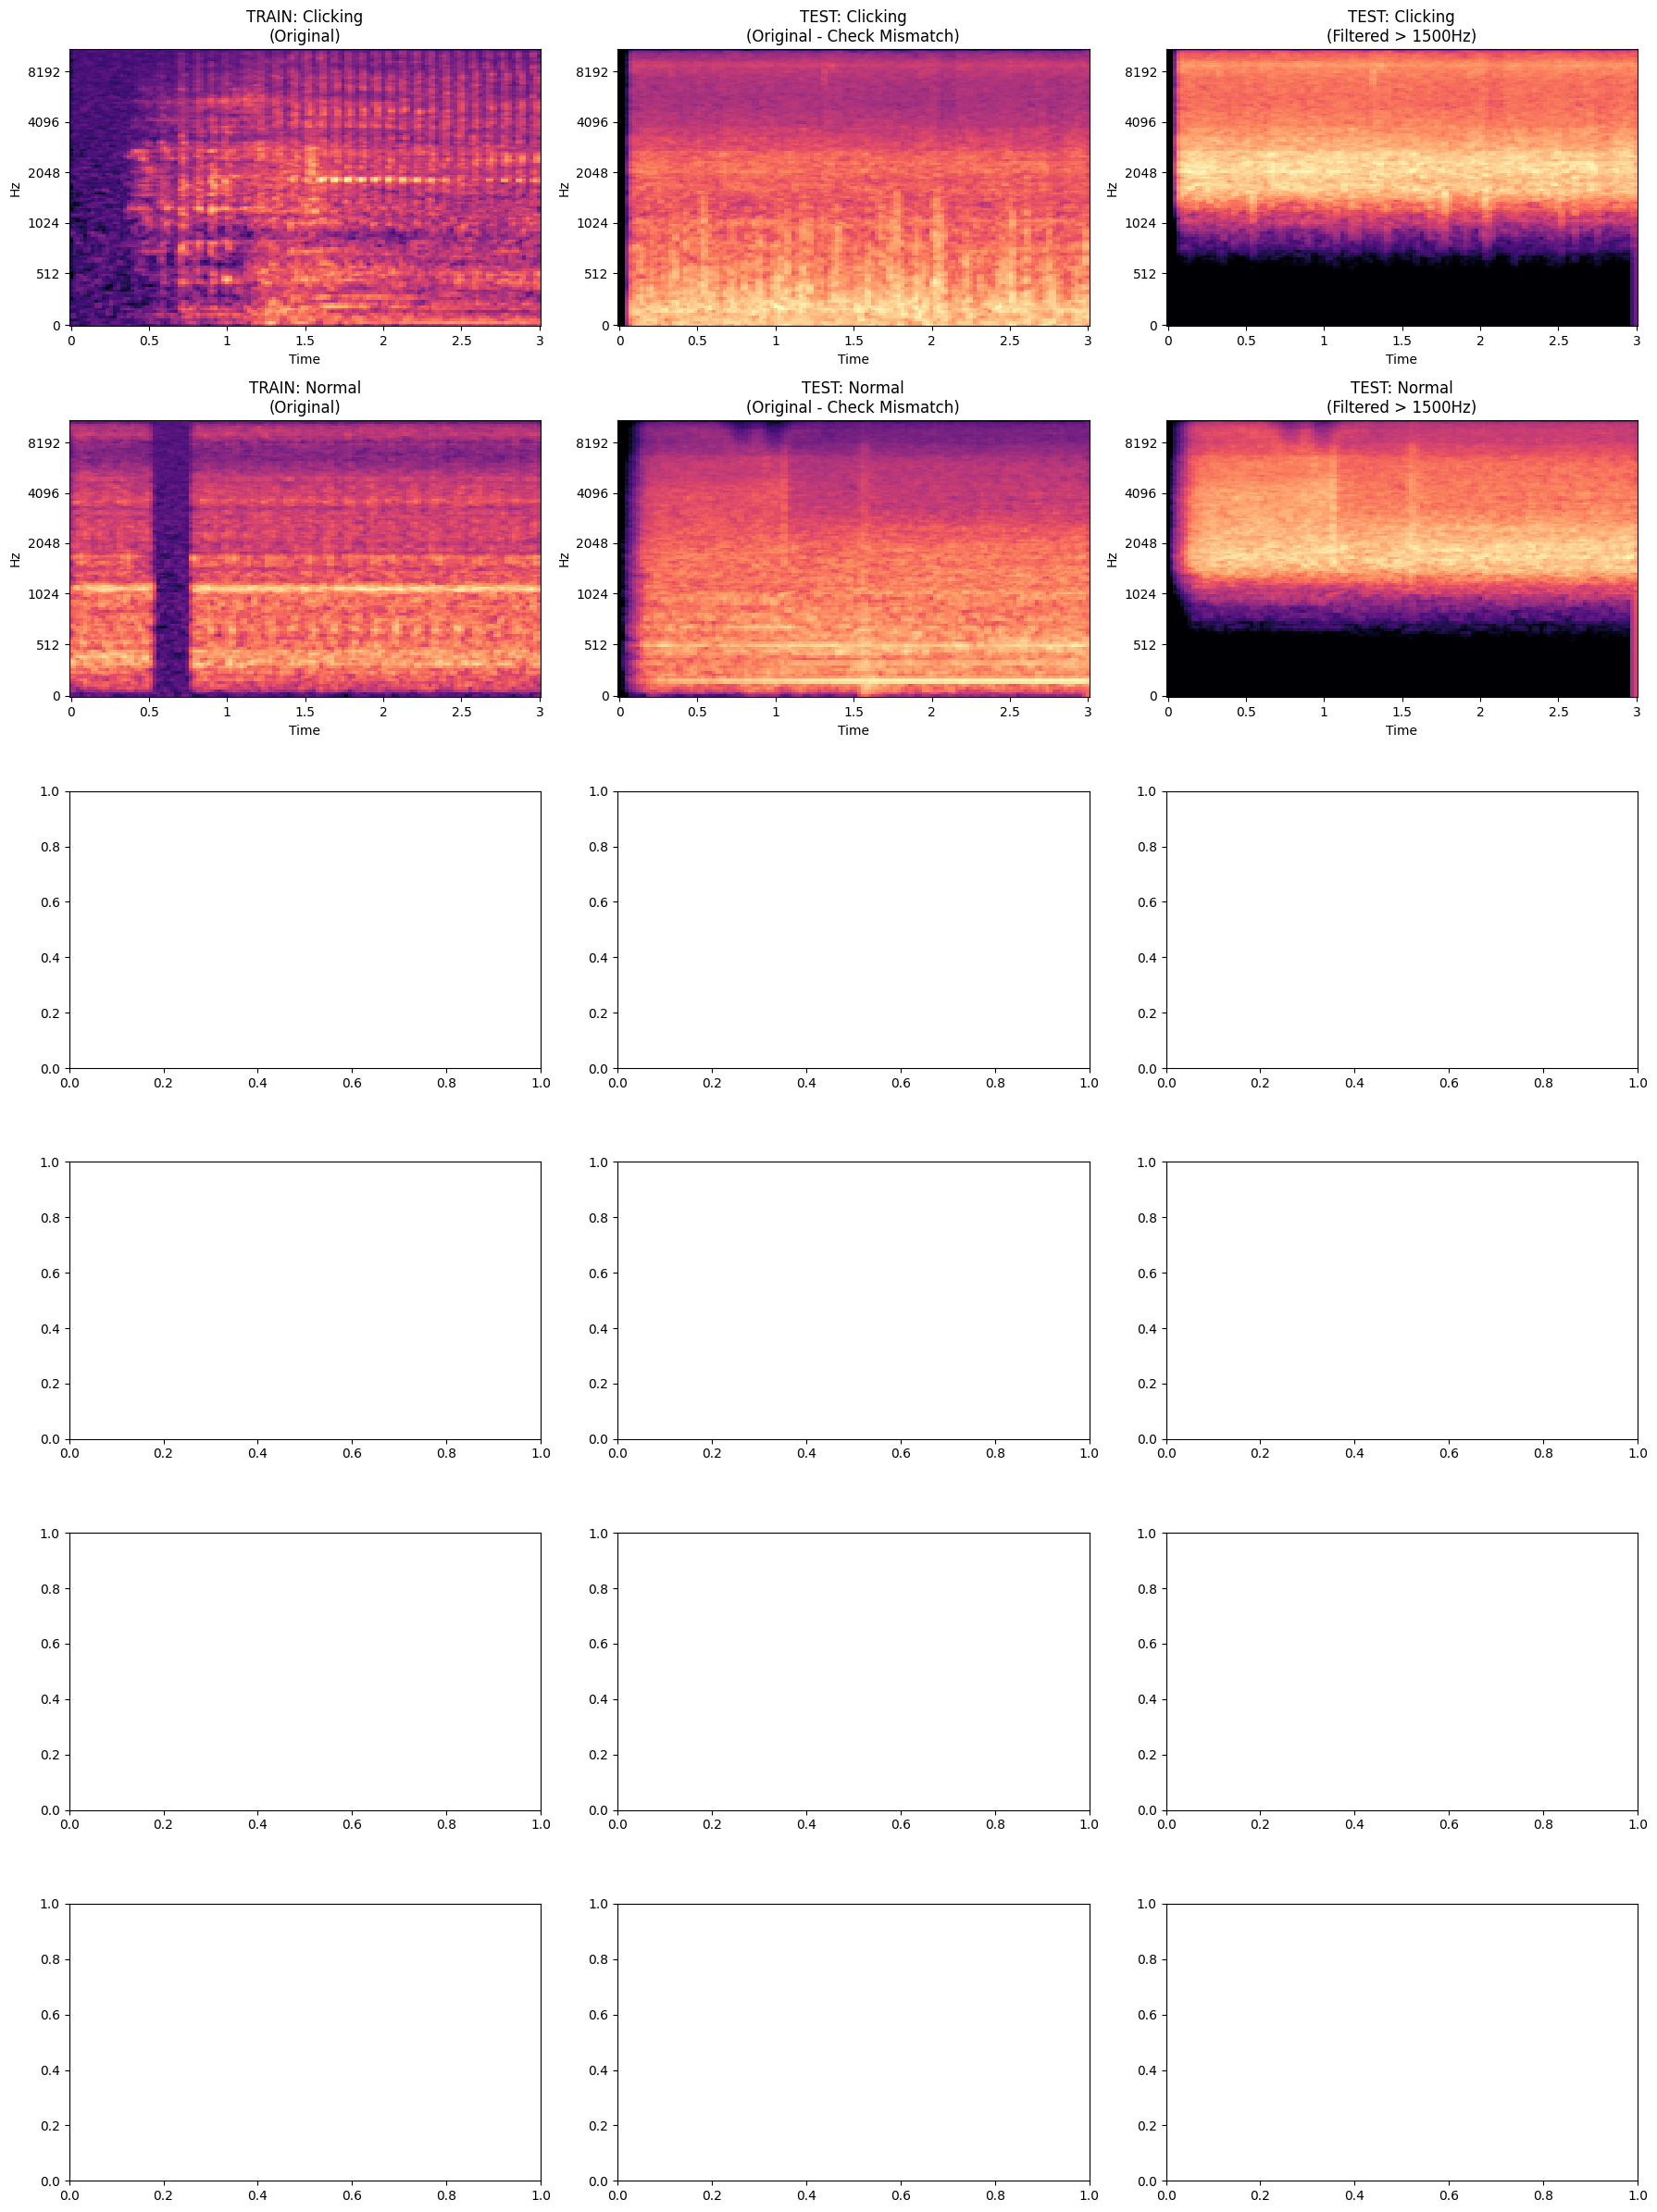

In [ ]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import random
import scipy.signal

# --- CONFIGURATION ---
# Base directories
TRAIN_BASE = "/content/drive/MyDrive/AS-Augmented_Engine_Data_2k"
TEST_BASE = "/content/drive/MyDrive/A-TESTTING/2k-orig-audio-testing"

# We map your specific folder names
CLASSES = ["Clicking", "Normal"]

# Dictionary to handle if you have 'Misfire_Filtered' vs 'Misfire'
# We will try to load 'Misfire_Filtered' for training if it exists
train_class_dirs = {}
for cls in CLASSES:
    if cls == "Misfire" and os.path.exists(os.path.join(TRAIN_BASE, "Misfire_Filtered")):
        train_class_dirs[cls] = os.path.join(TRAIN_BASE, "Misfire_Filtered")
    else:
        train_class_dirs[cls] = os.path.join(TRAIN_BASE, cls)

SAMPLE_RATE = 22050
DURATION = 3.0

# Define the High-Pass Filter (1500Hz)
def apply_filter(y, sr):
    sos = scipy.signal.butter(10, 1500, 'hp', fs=sr, output='sos')
    return scipy.signal.sosfilt(sos, y)

def get_random_audio(folder):
    if not os.path.exists(folder): return None, None
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.wav', '.mp3'))]
    if not files: return None, None
    f_path = os.path.join(folder, random.choice(files))
    y, sr = librosa.load(f_path, sr=SAMPLE_RATE, duration=DURATION)
    return y, sr

# --- PLOTTING ---
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(18, 24))
plt.subplots_adjust(hspace=0.4)

print(f"📊 Starting Global Audit...")

for i, cls in enumerate(CLASSES):
    # Paths
    train_dir = train_class_dirs[cls]
    test_dir = os.path.join(TEST_BASE, cls)

    # Load Audio
    y_train, sr = get_random_audio(train_dir)
    y_test, _ = get_random_audio(test_dir)

    # Handle Missing Data
    if y_train is None:
        print(f"⚠️ Missing Training Data for {cls}")
        for j in range(3): axes[i, j].text(0.5, 0.5, "MISSING DATA", ha='center')
        continue
    if y_test is None:
        print(f"⚠️ Missing Test Data for {cls}")
        for j in range(3): axes[i, j].text(0.5, 0.5, "MISSING DATA", ha='center')
        continue

    # 1. Train Original
    ax1 = axes[i, 0]
    S = librosa.feature.melspectrogram(y=y_train, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax1)
    ax1.set_title(f"TRAIN: {cls}\n(Original)")

    # 2. Test Original
    ax2 = axes[i, 1]
    S = librosa.feature.melspectrogram(y=y_test, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax2)
    ax2.set_title(f"TEST: {cls}\n(Original - Check Mismatch)")

    # 3. Test Filtered
    ax3 = axes[i, 2]
    y_test_filt = apply_filter(y_test, sr)
    S = librosa.feature.melspectrogram(y=y_test_filt, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax3)
    ax3.set_title(f"TEST: {cls}\n(Filtered > 1500Hz)")

plt.tight_layout()
plt.show()

# Task
Modify the `CLASSES` variable in cell `ryhFIaoUR34r` to contain only 'Clicking' and 'Normal'.

## Modify CLASSES list

### Subtask:
Modify the `CLASSES` variable in cell `ryhFIaoUR34r` to contain only 'Clicking' and 'Normal'.


## Summary:

### Data Analysis Key Findings
*   A subtask was initiated to modify the `CLASSES` variable.
*   The specific modification required was to update the `CLASSES` list in cell `ryhFIaoUR34r` to contain only 'Clicking' and 'Normal'.

### Insights or Next Steps
*   The next step involves executing the modification of the `CLASSES` variable as specified in the subtask.
